# **Loading & Read Dataset**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

movies_path= '/content/drive/MyDrive/DataAnalysisProject/tmdb.csv'

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import ast


# **columns for analysis**

In [ ]:
# 1. Load data
df = pd.read_csv(movies_path)

# 2. Select columns
columns_used = [
    'budget',
    'revenue',
    'vote_average',
    'vote_count',
    'genres',
    'release_date',
    'popularity',
    'runtime'
]

df = df[columns_used].copy()




#**Data OverView**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4947 entries, 0 to 4946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        4947 non-null   int64  
 1   revenue       4947 non-null   int64  
 2   vote_average  4947 non-null   float64
 3   vote_count    4947 non-null   int64  
 4   genres        4702 non-null   object 
 5   release_date  4946 non-null   object 
 6   popularity    4947 non-null   float64
 7   runtime       4699 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 309.3+ KB
None
        budget      revenue  vote_average  vote_count  \
0    237000000   2787965087           7.2       11800   
1    300000000    961000000           6.9        4500   
2  24500000000  44033730450           6.3        4466   
3    250000000   1084939099           7.6        9106   
4    260000000    284139100           6.1        2124   

                                              genres

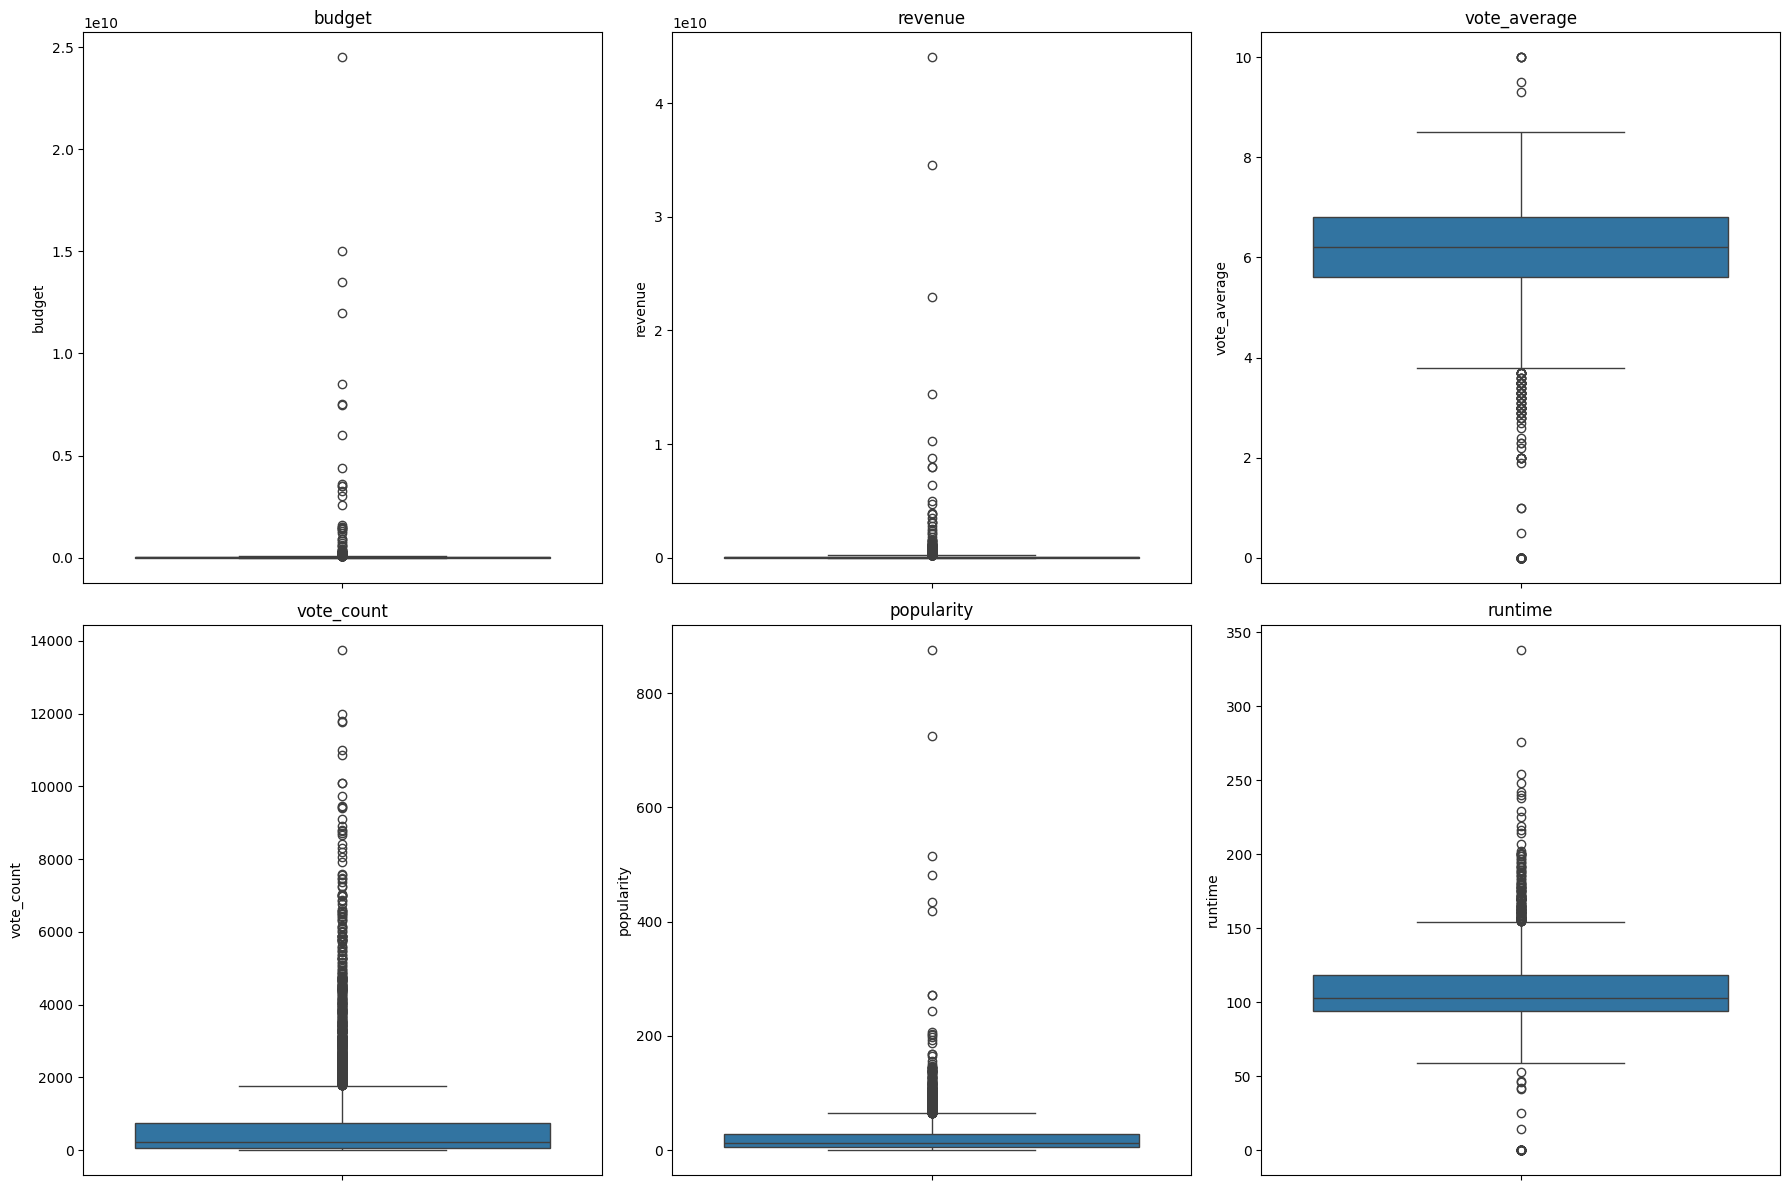

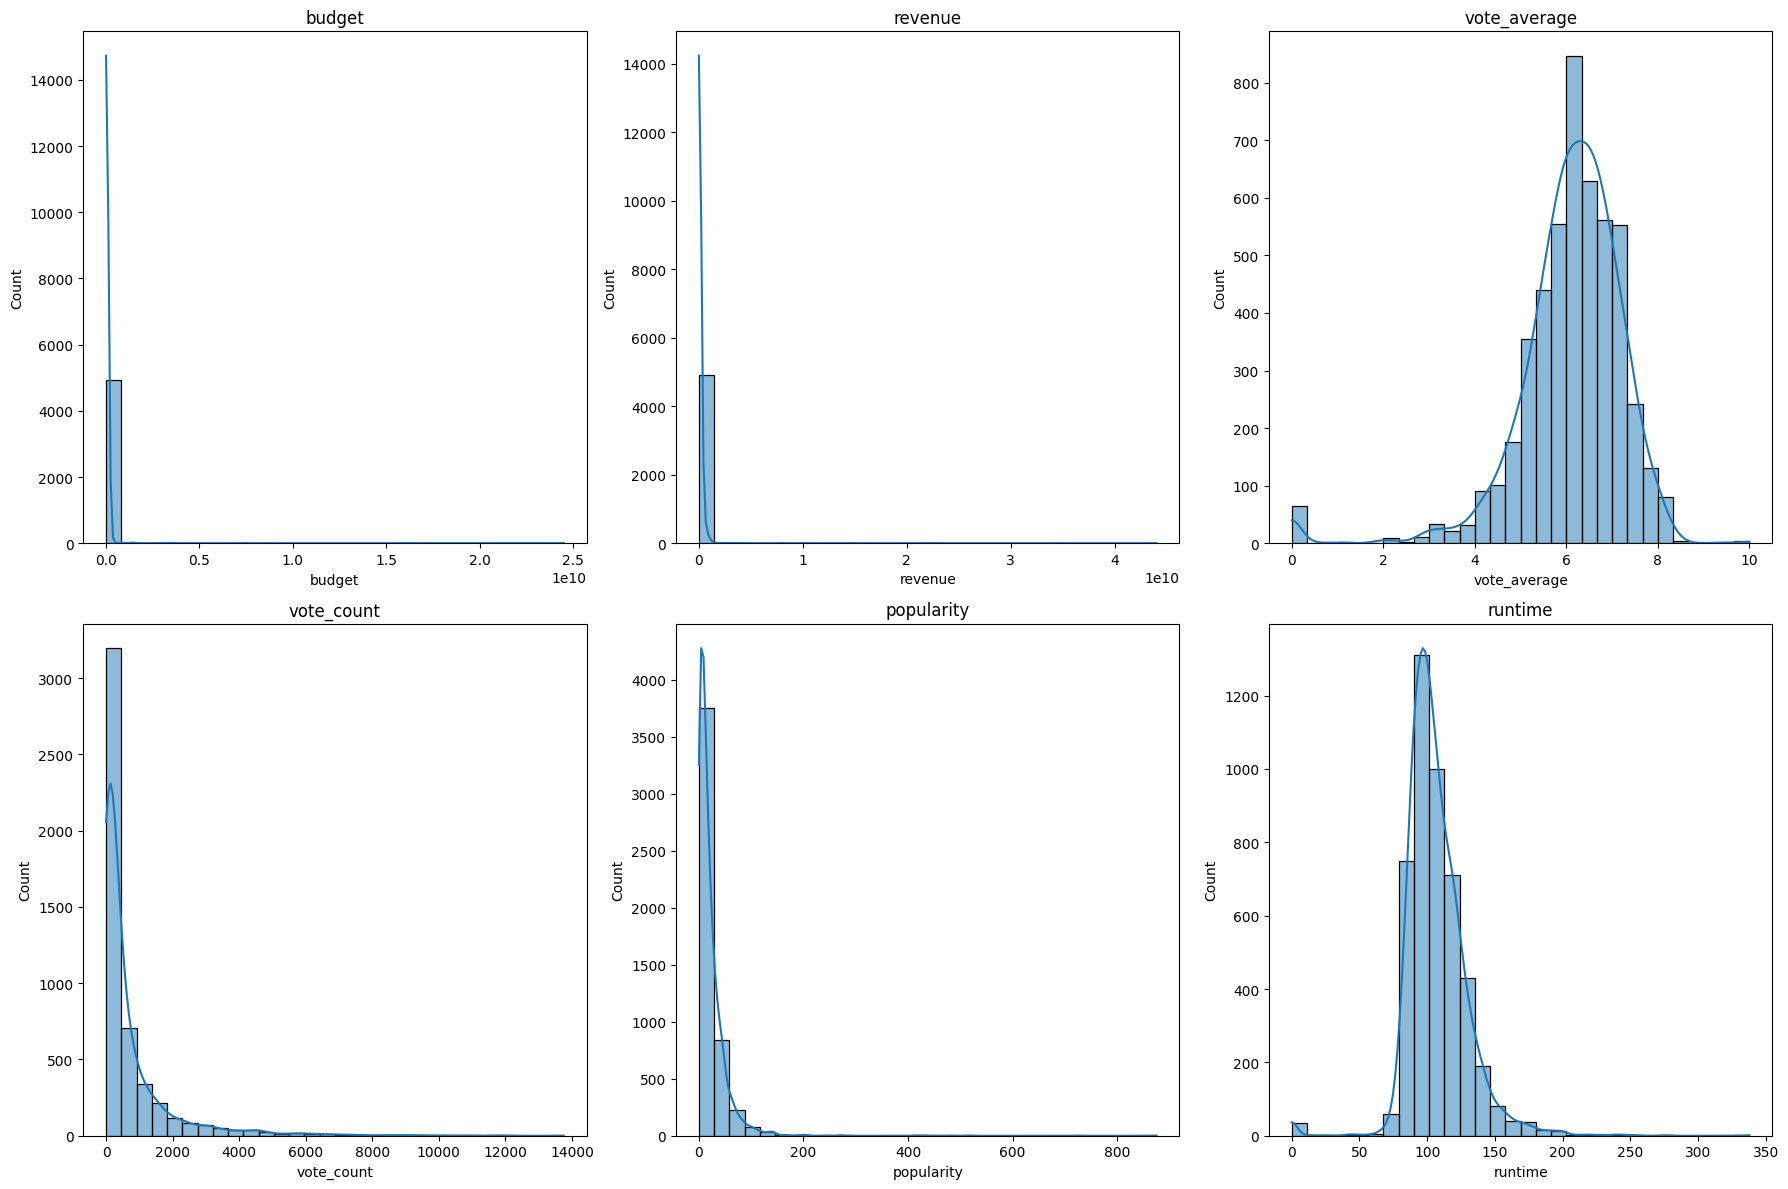

In [ ]:
#Movies Data overview
print(df.info())
print(df.head(), "\n")

#missing Values
print(df.isnull().sum())

#showing duplicates
duplicates = df.duplicated().sum()
print(f"=== Duplicates: {duplicates} rows ===\n")


# summary statistics
print(df.describe(), "\n")


#Outliers Detection (IQR method)
numeric_cols = ['budget', 'revenue', 'vote_average', 'vote_count', 'popularity', 'runtime']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"Column '{col}' has {outliers.shape[0]} outliers")



# Visualizations
plt.figure(figsize=(18,12))
for i, col in enumerate(numeric_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()



#Histogram / Distribution
plt.figure(figsize=(18,12))
for i, col in enumerate(numeric_cols):
    plt.subplot(2,3,i+1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()






# **Handling&Cleaning Data**



In [ ]:

#handle missing values


#(genres)
df['genres'] = df['genres'].fillna('[]')


#( Release data )
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df = df.dropna(subset=['release_date'])


#runtime
df['runtime'] = df['runtime'].replace(0, np.nan)
df['runtime'] = df['runtime'].fillna(df['runtime'].median())


#Handle zero values
for col in ['budget', 'revenue']:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())



#Extract year fro release date
df['year'] = df['release_date'].dt.year  #for trend analysis&feature eng



#parse genres JSON Format
def extract_genres(genre_str):
    try:
        return [g['name'] for g in ast.literal_eval(genre_str)]
    except:
        return []

df['genres'] = df['genres'].apply(extract_genres)

#remove [] rows in genres
df = df[df['genres'].apply(lambda x: len(x) > 0)]



#handle outliers

outlier_cols = ['budget', 'revenue', 'vote_count', 'popularity', 'runtime']

for col in outlier_cols:
    upper_limit = df[col].quantile(0.99)
    df = df[df[col] <= upper_limit]


#Checking new Dataset
print(df.info())
print(df.isnull().sum())



clean_path = '/content/drive/MyDrive/DataAnalysisProject/tmdb_cleaned_movies.csv'
df.to_csv(clean_path, index=False)

print("Cleaned dataset saved")

<class 'pandas.core.frame.DataFrame'>
Index: 4444 entries, 15 to 4946
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   budget        4444 non-null   float64       
 1   revenue       4444 non-null   float64       
 2   vote_average  4444 non-null   float64       
 3   vote_count    4444 non-null   int64         
 4   genres        4444 non-null   object        
 5   release_date  4444 non-null   datetime64[ns]
 6   popularity    4444 non-null   float64       
 7   runtime       4444 non-null   float64       
 8   year          4444 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(1), int64(1), object(1)
memory usage: 329.8+ KB
None
budget          0
revenue         0
vote_average    0
vote_count      0
genres          0
release_date    0
popularity      0
runtime         0
year            0
dtype: int64
Cleaned dataset saved


# **checking for graphs**

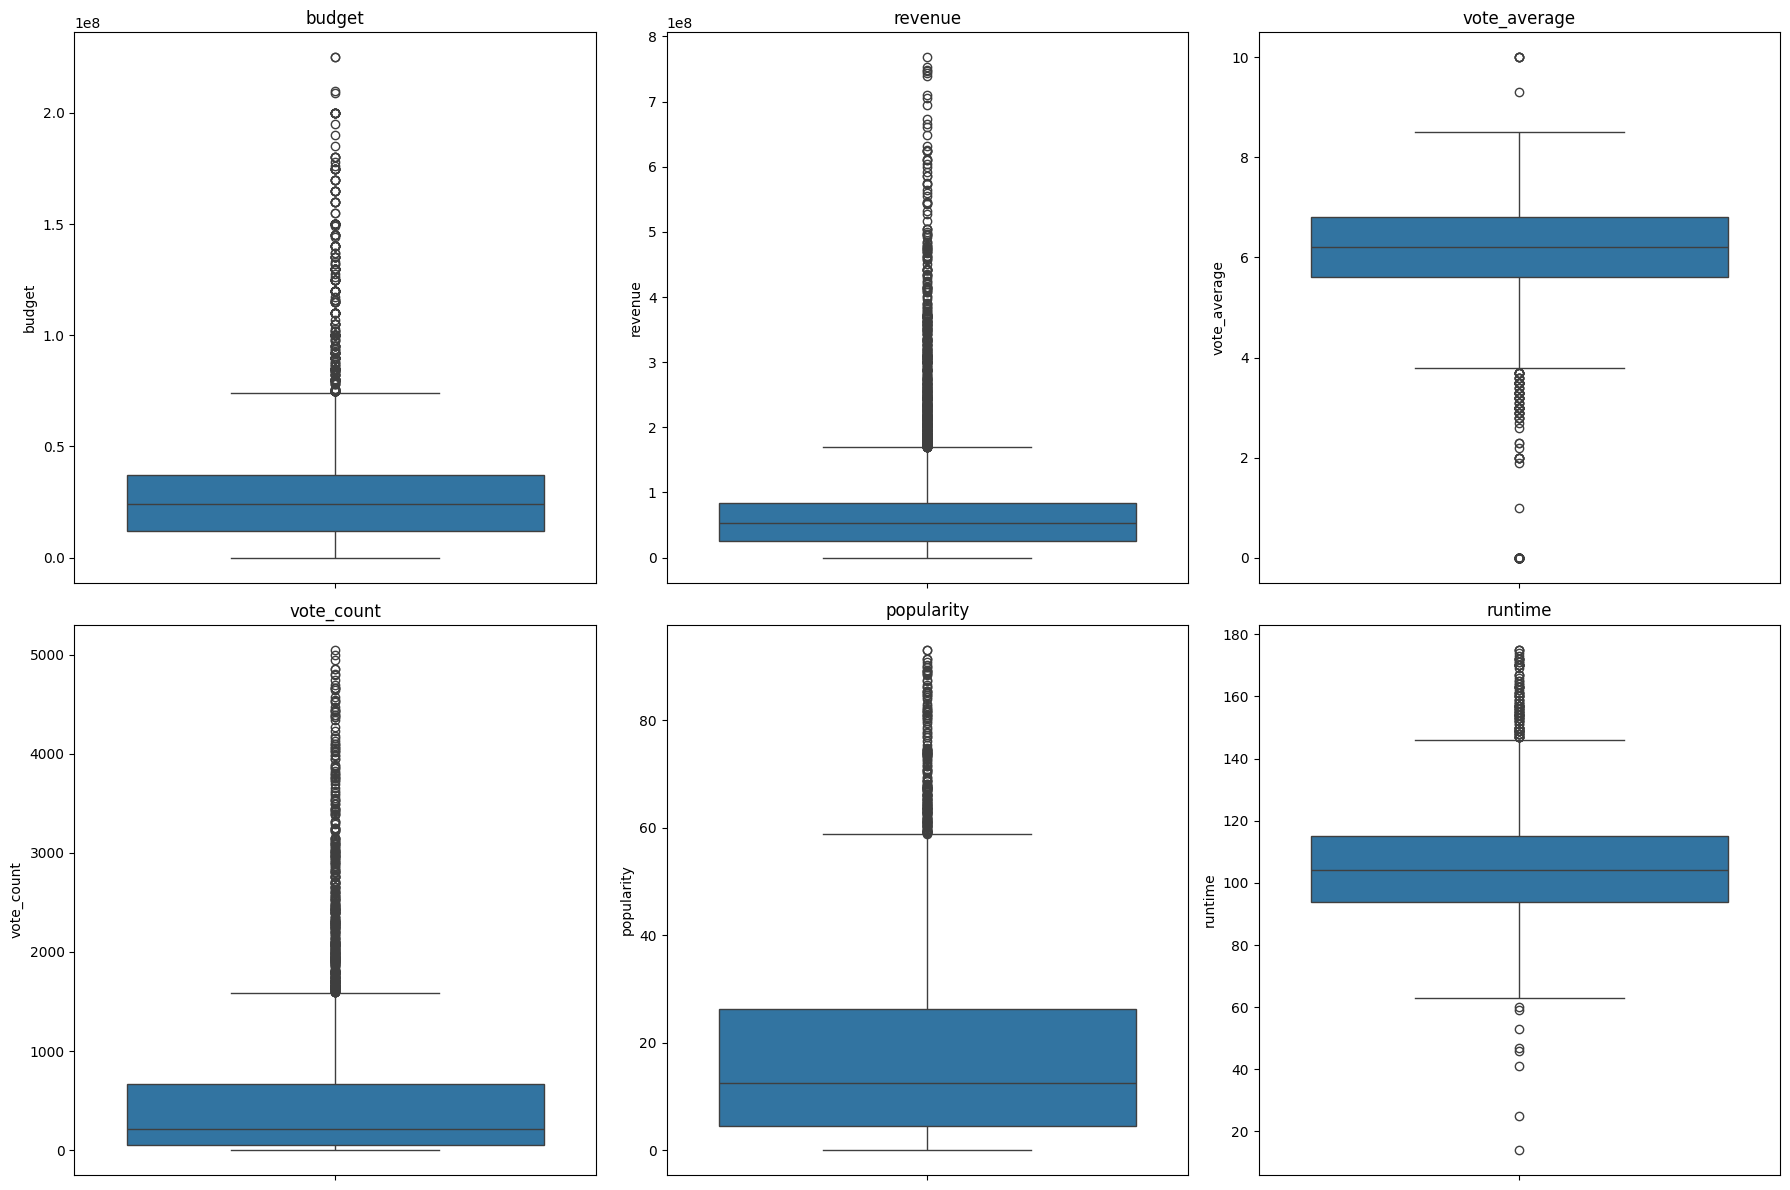

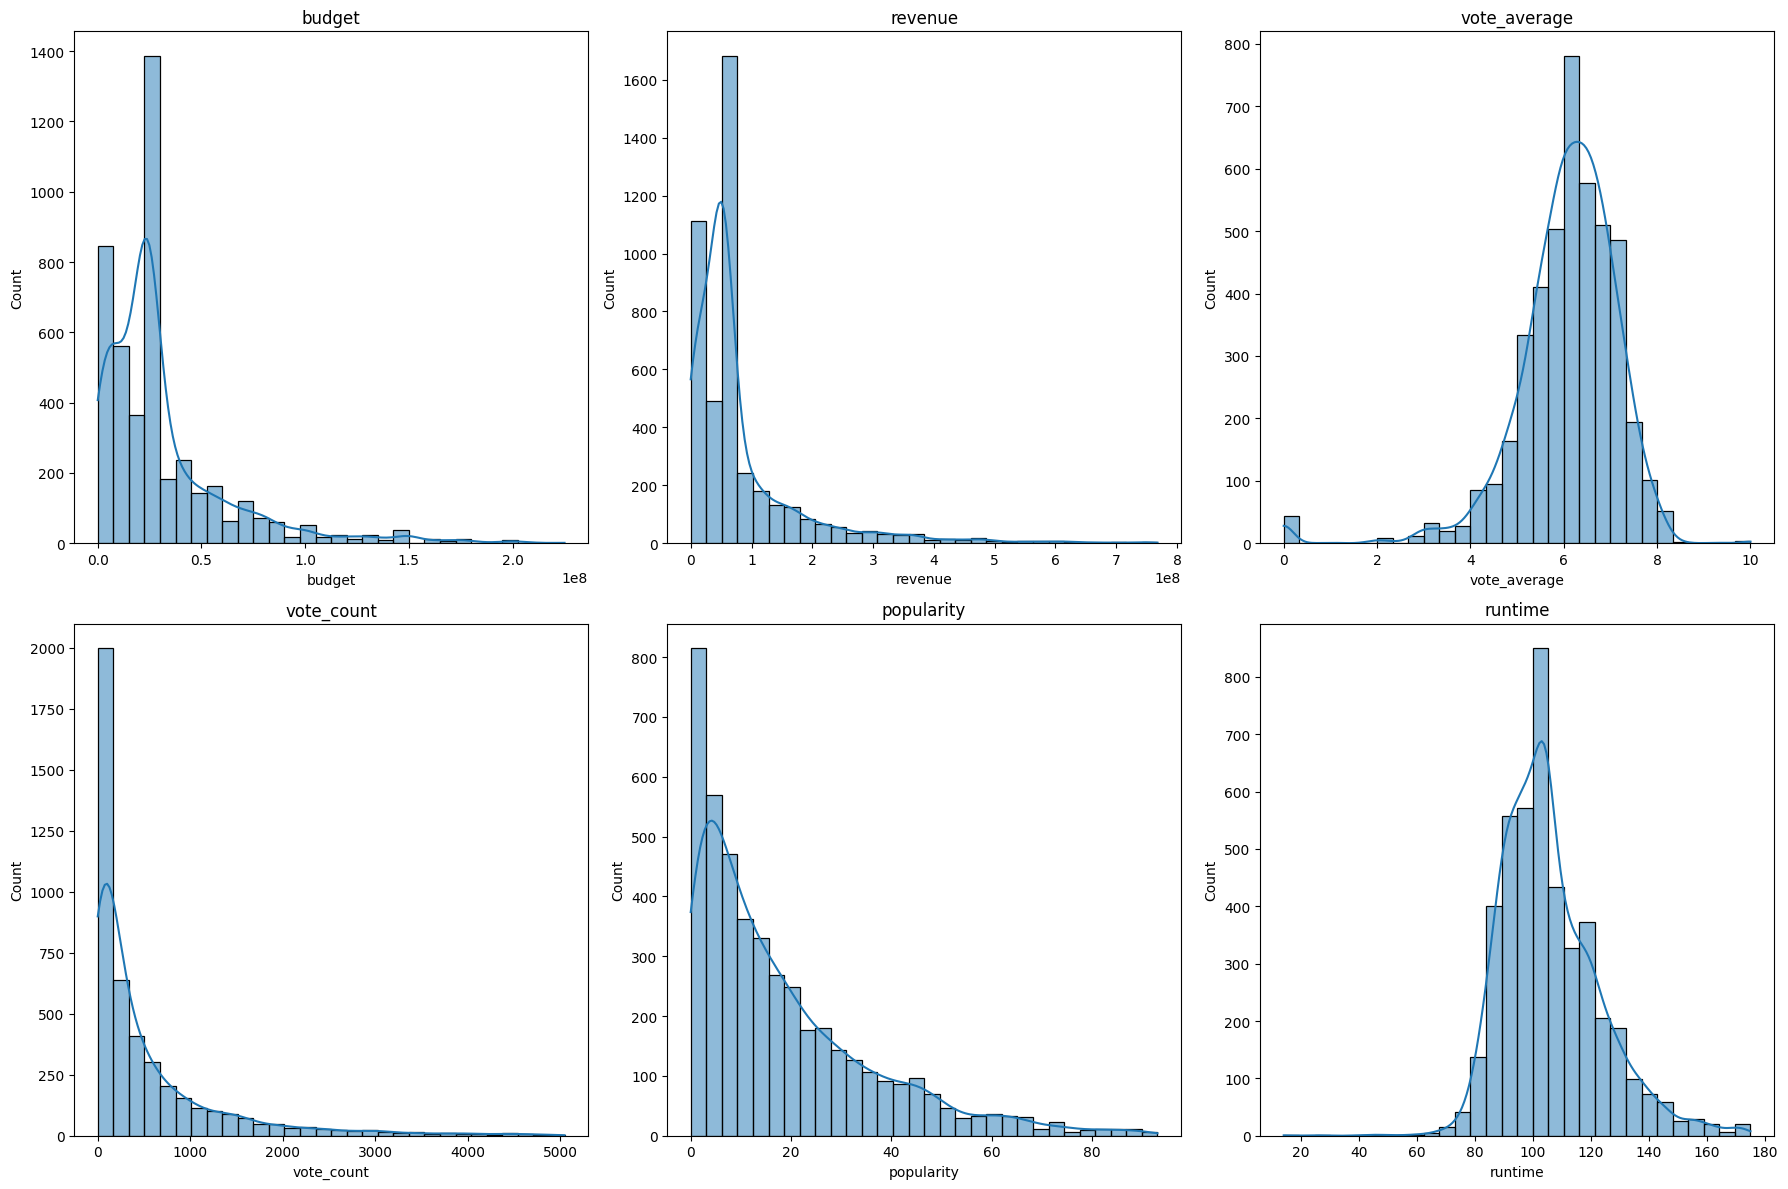

In [ ]:

# Visualizations
plt.figure(figsize=(18,12))
for i, col in enumerate(numeric_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


#Histogram / Distribution
plt.figure(figsize=(18,12))
for i, col in enumerate(numeric_cols):
    plt.subplot(2,3,i+1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# **EDA & VISUALIZATION**

In [ ]:
#creating new features
df = pd.read_csv('/content/drive/MyDrive/DataAnalysisProject/tmdb_cleaned_movies.csv')
df.describe()
# Profit = revenue - budget
df['profit'] = df['revenue'] - df['budget']

# ROI (Return on Investment)
df['ROI'] = df['profit'] / df['budget']

# **1)Rating Histogram for 'Vote_Average**

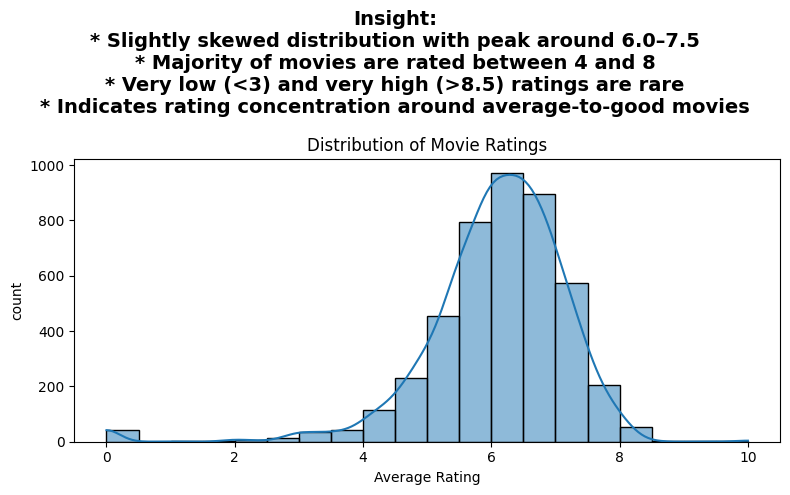

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['vote_average'],bins=20, kde=True)

plt.title('Distribution of Movie Ratings')
plt.xlabel('Average Rating')
plt.ylabel('count')


plt.suptitle(
         "Insight:\n"
         "* Slightly skewed distribution with peak around 6.0–7.5\n"
         "* Majority of movies are rated between 4 and 8\n"
         "* Very low (<3) and very high (>8.5) ratings are rare\n"
         "* Indicates rating concentration around average-to-good movies",
         fontsize=14, fontweight='bold', ha='center', va='top', y=0.98)


plt.subplots_adjust(top=0.82)

plt.tight_layout()


plt.show()

# **2**)Renevue histogram


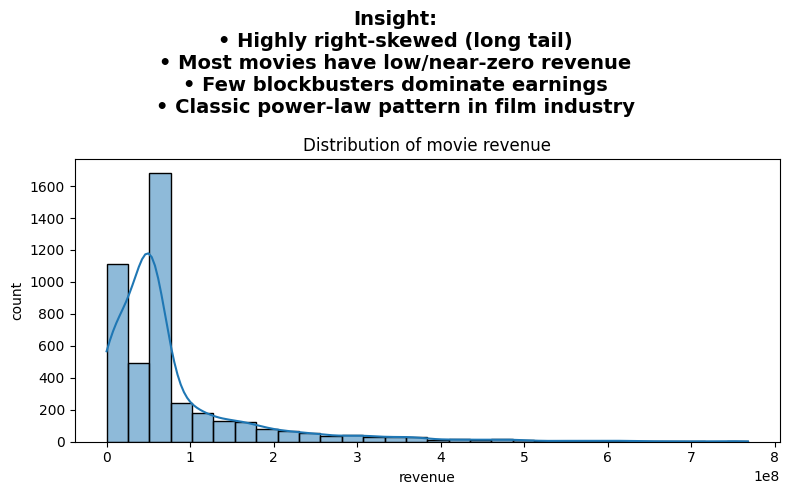

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['revenue'],bins=30,kde=True)

plt.title('Distribution of movie revenue')
plt.xlabel('revenue')
plt.ylabel('count')



plt.suptitle(
         "Insight:\n"
         "• Highly right-skewed (long tail)\n"
         "• Most movies have low/near-zero revenue\n"
         "• Few blockbusters dominate earnings\n"
         "• Classic power-law pattern in film industry",
         fontsize=14, fontweight='bold', ha='center', va='top', y=0.98)


plt.subplots_adjust(top=0.82)

plt.tight_layout()



plt.show()

# **3**)Runtime histogram

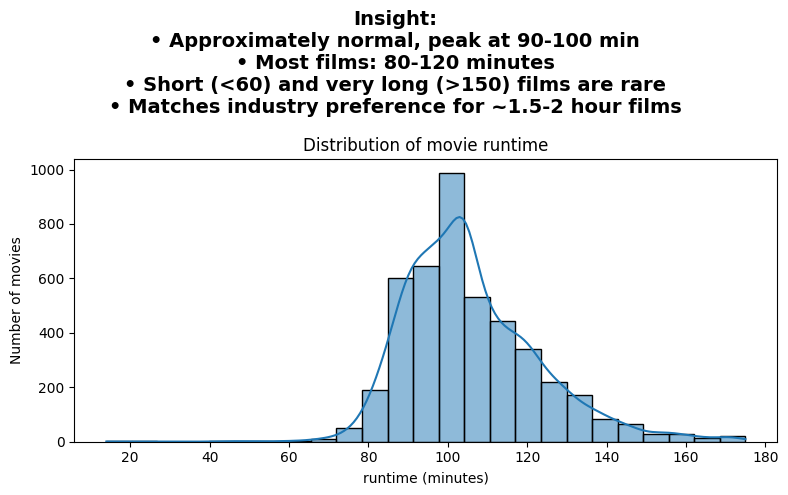

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['runtime'],bins=25,kde=True)

plt.title('Distribution of movie runtime')
plt.xlabel('runtime (minutes)')
plt.ylabel('Number of movies')




plt.suptitle("Insight:\n"
         "• Approximately normal, peak at 90-100 min\n"
         "• Most films: 80-120 minutes\n"
         "• Short (<60) and very long (>150) films are rare\n"
         "• Matches industry preference for ~1.5-2 hour films",
         fontsize=14, fontweight='bold', ha='center', va='top', y=0.98)


plt.subplots_adjust(top=0.82)

plt.tight_layout()

plt.show()


# **4)profit histogram**

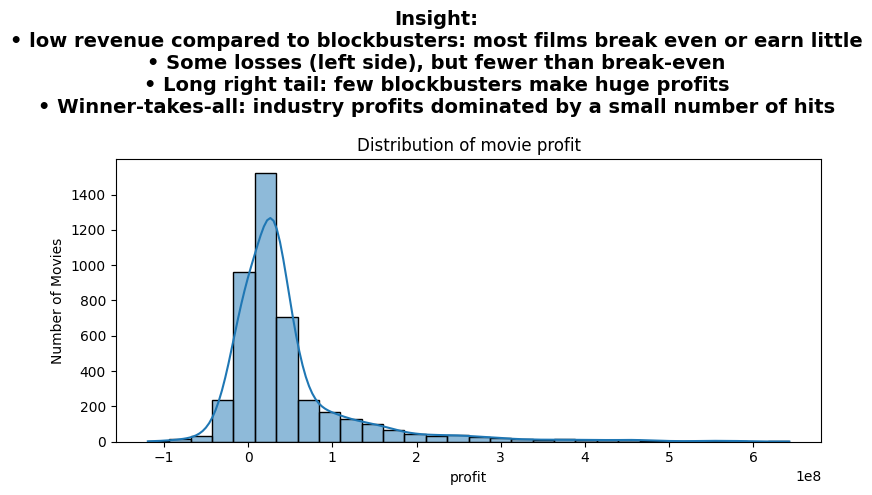

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['profit'], bins=30, kde=True)

plt.title('Distribution of movie profit')
plt.xlabel('profit')
plt.ylabel('Number of Movies')


plt.suptitle("Insight:\n"
             "• low revenue compared to blockbusters: most films break even or earn little\n"
             "• Some losses (left side), but fewer than break-even\n"
             "• Long right tail: few blockbusters make huge profits\n"
             "• Winner-takes-all: industry profits dominated by a small number of hits",
             fontsize=14, fontweight='bold', ha='center', va='top', y=0.98)

plt.subplots_adjust(top=0.82)
plt.tight_layout()
plt.show()



#**5)boxplots ber genre(ratings)**


In [ ]:
df_exploded = df.copy()
df_exploded = df_exploded.explode('genres')

In [ ]:
top_genres = (
    df_exploded['genres']
    .value_counts()
    .head(10)
    .index
)

df_top = df_exploded[df_exploded['genres'].isin(top_genres)]


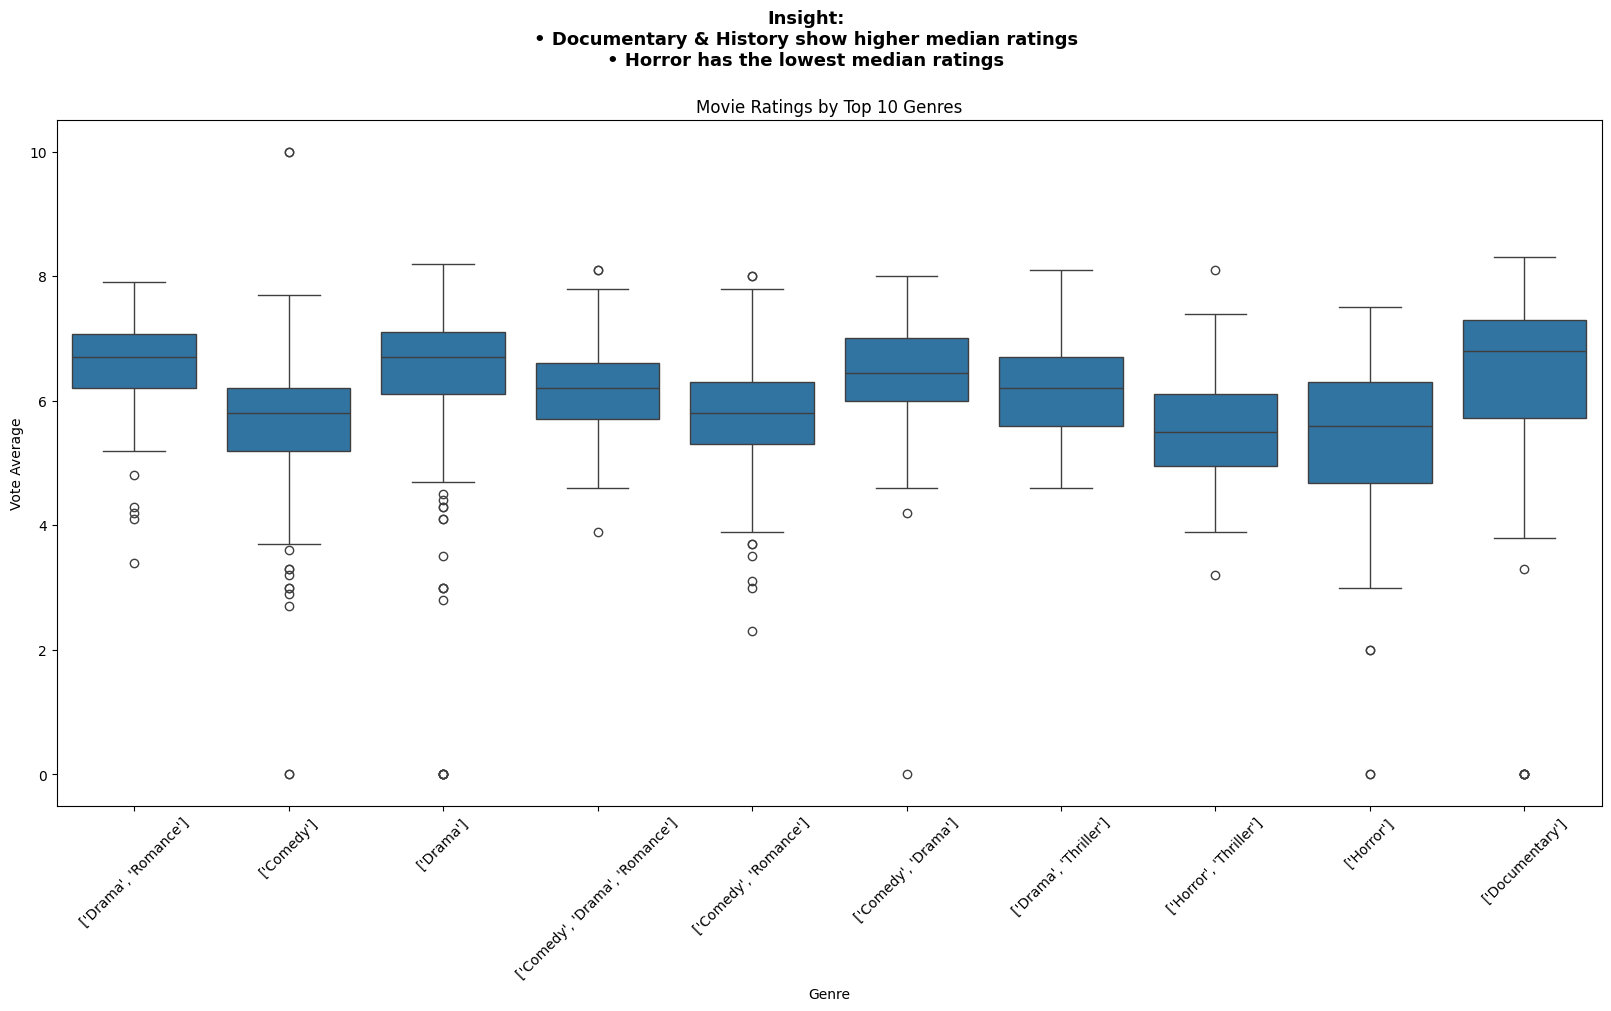

In [ ]:

plt.figure(figsize=(16,10), constrained_layout=True)

sns.boxplot(
    data=df_top,
    x='genres',
    y='vote_average'
)

plt.xticks(rotation=45)
plt.title('Movie Ratings by Top 10 Genres')
plt.xlabel('Genre')
plt.ylabel('Vote Average')

plt.suptitle(
    "Insight:\n"
    "• Documentary & History show higher median ratings\n"
    "• Horror has the lowest median ratings\n",
    fontsize=13,
    fontweight='bold'
)

plt.show()



# **6)Scatter:budget vs Revenue**

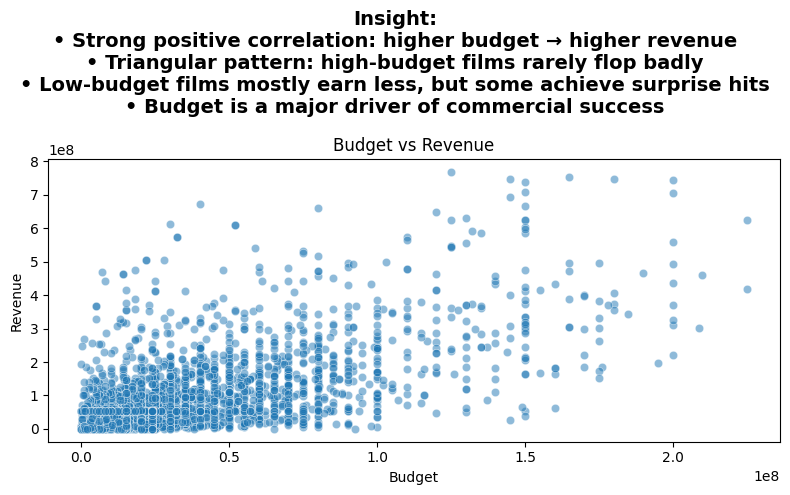

In [ ]:
df[['budget','revenue']].corr()
plt.figure(figsize=(8,5))
sns.scatterplot(x='budget', y='revenue', data=df, alpha=0.5)

plt.title('Budget vs Revenue')
plt.xlabel('Budget')
plt.ylabel('Revenue')


plt.suptitle("Insight:\n"
             "• Strong positive correlation: higher budget → higher revenue\n"
             "• Triangular pattern: high-budget films rarely flop badly\n"
             "• Low-budget films mostly earn less, but some achieve surprise hits\n"
             "• Budget is a major driver of commercial success",
             fontsize=14, fontweight='bold', ha='center', va='top', y=0.98)


plt.subplots_adjust(top=0.82)
plt.tight_layout()
plt.show()


# **7)scatter:budget vs ratings**

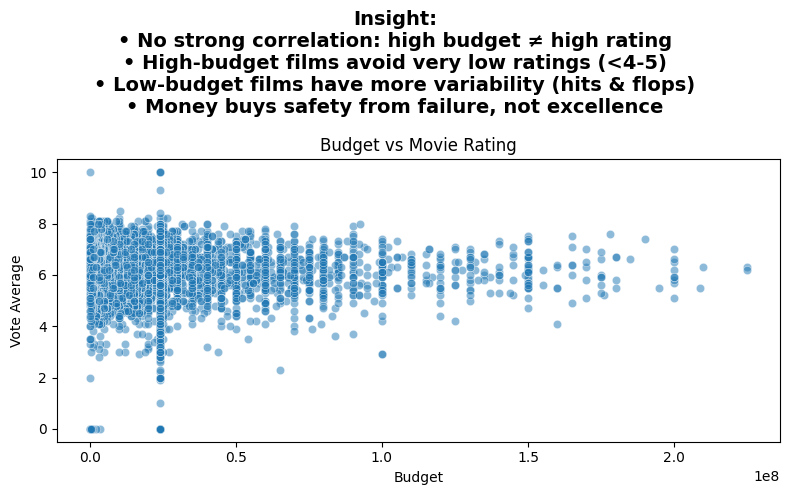

In [ ]:
df[['budget','vote_average']].corr()
plt.figure(figsize=(8,5))
sns.scatterplot(x='budget', y='vote_average', data=df, alpha=0.5)
plt.title('Budget vs Movie Rating')
plt.xlabel('Budget')
plt.ylabel('Vote Average')


plt.suptitle("Insight:\n"
             "• No strong correlation: high budget ≠ high rating\n"
             "• High-budget films avoid very low ratings (<4-5)\n"
             "• Low-budget films have more variability (hits & flops)\n"
             "• Money buys safety from failure, not excellence",
             fontsize=14, fontweight='bold', ha='center', va='top', y=0.98)

plt.subplots_adjust(top=0.82)
plt.tight_layout()


plt.show()


# **8)correlation heatmap**

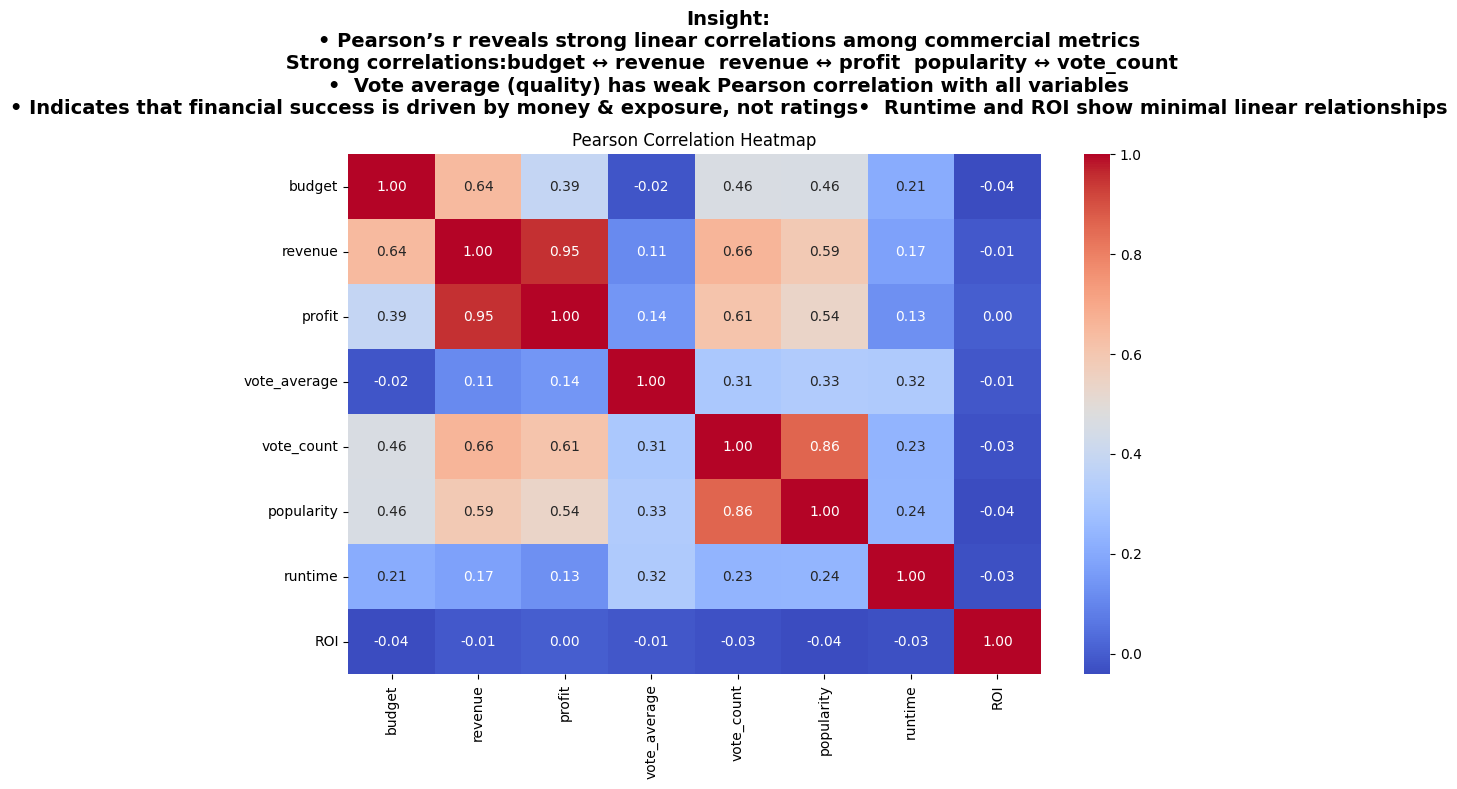

In [ ]:
numeric_cols = ['budget','revenue','profit','vote_average','vote_count','popularity','runtime','ROI']
corr_matrix = df[numeric_cols].corr(method='pearson')

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")


plt.suptitle("Insight:\n"
             "• Pearson’s r reveals strong linear correlations among commercial metrics\n"
             " Strong correlations:budget ↔ revenue  revenue ↔ profit  popularity ↔ vote_count\n"
             "•  Vote average (quality) has weak Pearson correlation with all variables\n"
             "• Indicates that financial success is driven by money & exposure, not ratings"
             "•  Runtime and ROI show minimal linear relationships",
             fontsize=14, fontweight='bold', ha='center', va='top', y=0.98)

plt.subplots_adjust(top=0.82)
plt.tight_layout()


plt.show()


# **9)Trend:Average Rating per Year**

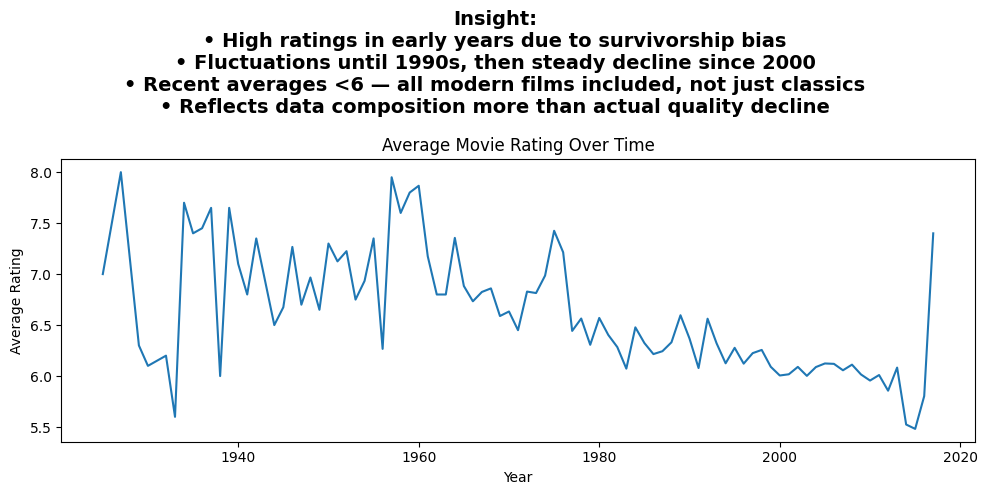

In [ ]:
avg_rating_year = df.groupby('year')['vote_average'].mean()

plt.figure(figsize=(10,5))
avg_rating_year.plot()

plt.title('Average Movie Rating Over Time')
plt.xlabel('Year')
plt.ylabel('Average Rating')

plt.suptitle("Insight:\n"
             "• High ratings in early years due to survivorship bias\n"
             "• Fluctuations until 1990s, then steady decline since 2000\n"
             "• Recent averages <6 — all modern films included, not just classics\n"
             "• Reflects data composition more than actual quality decline",
             fontsize=14, fontweight='bold', ha='center', va='top', y=0.98)

plt.subplots_adjust(top=0.82)
plt.tight_layout()


plt.show()

# **Feature engineering&selection**

In [ ]:
#feature 1 (profit)
df['profit'] = df['revenue'] - df['budget']

In [ ]:
#feature 2 (ROI)
df['ROI'] = df['profit'] / df['budget']
df['ROI'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['ROI'].fillna(0, inplace=True)


/tmp/ipython-input-2042093861.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ROI'].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipython-input-2042093861.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [ ]:
#feature3&4 (log transformation) to reduce skewness /outlier
df['budget_log'] = np.log1p(df['budget'])
df['revenue_log'] = np.log1p(df['revenue'])


# **Encoding&Scaling**

In [ ]:
def extract_main_genre(genres):
    if not isinstance(genres, str):
        return np.nan
    try:
        genre_list = ast.literal_eval(genres)
        if isinstance(genre_list, list) and len(genre_list) > 0:
            return genre_list[0]
    except:
        return np.nan



df['main_genre'] = df['genres'].apply(extract_main_genre)



#One-Hot Encoding(Genres)
genre_dummies = pd.get_dummies(df['main_genre'], prefix='genre')
df = pd.concat([df, genre_dummies], axis=1)




In [ ]:
#Scaling(StandardScaler)

from sklearn.preprocessing import StandardScaler

num_features = [
    'budget_log',
    'revenue_log',
    'profit',
    'ROI',
    'vote_average',
    'vote_count',
    'runtime'
]

scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])


# **Feature Selecion**

In [ ]:
#Method 1 (correlation filter) redundant


corr_matrix = df[num_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
df_corr_filtered = df.drop(columns=to_drop)



#method 2 (Lasso Feature Selection)
from sklearn.linear_model import Lasso

X = df_corr_filtered[num_features].drop(columns=['revenue_log'], errors='ignore')
y = df['revenue_log']

lasso = Lasso(alpha=0.01)
lasso.fit(X, y)
lasso_features = X.columns[lasso.coef_ != 0]

print("Lasso Selected Features:", list(lasso_features))

#Method 3 (RFE (Recursive Feature Elimination))
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X, y)
rfe_features = X.columns[rfe.support_]

print("RFE Selected Features:", list(rfe_features))




Lasso Selected Features: ['budget_log', 'profit', 'ROI', 'vote_average', 'runtime']
RFE Selected Features: ['budget_log', 'profit', 'ROI', 'vote_average', 'runtime']


In [ ]:
#Final Selected Features (To PCA)


final_features = list(
    set(lasso_features)
    .intersection(set(rfe_features))
)

final_features


['budget_log', 'profit', 'ROI', 'vote_average', 'runtime']

In [ ]:

print("Final Features:", final_features)
print("Count:", len(final_features))


Final Features: ['budget_log', 'profit', 'ROI', 'vote_average', 'runtime']
Count: 5


# **Statistical Analysis & Hypothesis Testing**

---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, norm, lognorm

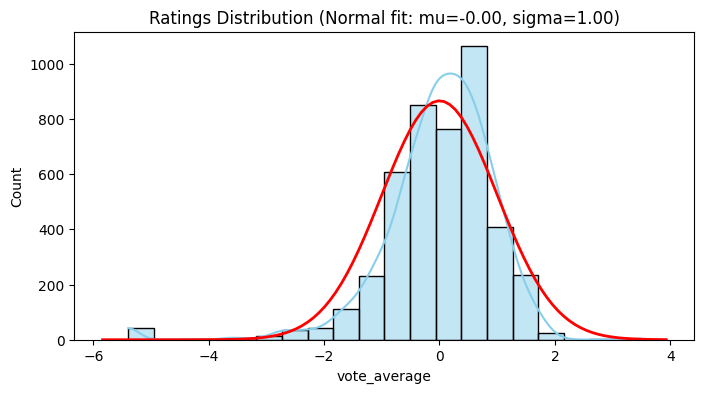

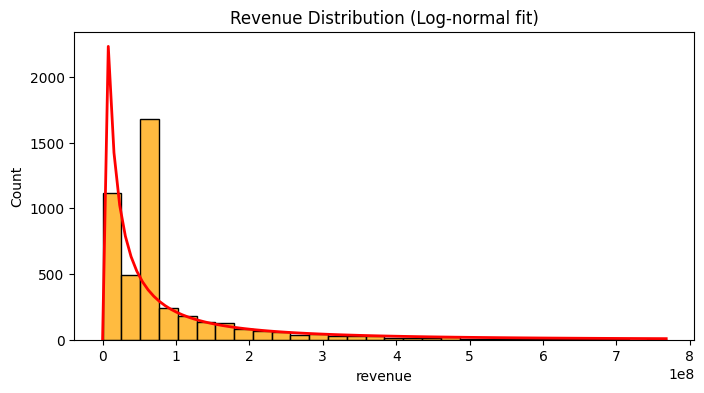

In [ ]:
# --- Step 2: Plot probability distributions ---
# Ratings histogram + Normal fit
plt.figure(figsize=(8,4))
sns.histplot(df['vote_average'], kde=True, color='skyblue', bins=20)
mu, sigma = norm.fit(df['vote_average'])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p*len(df['vote_average'])* (xmax-xmin)/20, 'r', linewidth=2)
plt.title(f'Ratings Distribution (Normal fit: mu={mu:.2f}, sigma={sigma:.2f})')
plt.show()

# Revenue histogram + log-normal fit
plt.figure(figsize=(8,4))
sns.histplot(df['revenue'], kde=False, color='orange', bins=30)
shape, loc, scale = lognorm.fit(df['revenue'][df['revenue']>0], floc=0)
x = np.linspace(1, df['revenue'].max(), 100)
pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)
plt.plot(x, pdf*len(df['revenue'])* (x.max()/30), 'r', linewidth=2)
plt.title(f'Revenue Distribution (Log-normal fit)')
plt.show()

In [ ]:
#====================Hypothesis Testing======================
#             ========== T-Test ===========
action_ratings = df[df['genres'].apply(lambda x: 'Action' in x)]['vote_average']
drama_ratings = df[df['genres'].apply(lambda x: 'Drama' in x)]['vote_average']

t_stat, p_val = ttest_ind(action_ratings, drama_ratings, equal_var=False)
print("T-test (Action vs Drama ratings)")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.5f}")
if p_val < 0.05:
    print("Conclusion: Reject H0 → Action and Drama ratings differ significantly\n")
else:
    print("Conclusion: Fail to reject H0 → No significant difference\n")

T-test (Action vs Drama ratings)
t-statistic = -11.800, p-value = 0.00000
Conclusion: Reject H0 → Action and Drama ratings differ significantly



In [ ]:
# ---  ANOVA (5 genres ratings) ---
genres_list = ['Action', 'Drama', 'Comedy', 'Adventure', 'Fantasy']
groups = [df[df['genres'].apply(lambda x: genre in x)]['vote_average'] for genre in genres_list]

f_stat, p_val = f_oneway(*groups)
print("ANOVA (5 genres ratings)")
print(f"F-statistic = {f_stat:.3f}, p-value = {p_val:.5f}")
if p_val < 0.05:
    print("Conclusion: Reject H0 → At least one genre has different mean rating\n")
else:
    print("Conclusion: Fail to reject H0 → No significant difference\n")

ANOVA (5 genres ratings)
F-statistic = 58.201, p-value = 0.00000
Conclusion: Reject H0 → At least one genre has different mean rating



In [ ]:
  # --- Step 1: Create genre flags ---
genres_list = ['Action', 'Drama', 'Comedy', 'Adventure', 'Fantasy']
for genre in genres_list:
    df[genre+'_flag'] = df['genres'].apply(lambda x: genre in x)

# --- Step 2: Create High Revenue flag ---
threshold = df['revenue'].median()  # ay film el revenue akbar mn el median yeb2a high
df['high_revenue'] = df['revenue'] > threshold

# --- Step 3: Chi-square test for each genre ---
# 3ashan t-test&anova checking comparing on mean
for genre in genres_list:
    contingency = pd.crosstab(df[genre+'_flag'], df['high_revenue'])
    chi2, p, dof, expected = chi2_contingency(contingency)

    print(f"Chi-square test: {genre} × High Revenue")
    print(f"chi2 = {chi2:.3f}, p-value = {p:.5f}")
    if p < 0.05:
        print(f"Conclusion: Reject H0 → {genre} genre is associated with high revenue\n")
    else:
        print(f"Conclusion: Fail to reject H0 → No association for {genre}\n")

Chi-square test: Action × High Revenue
chi2 = 112.515, p-value = 0.00000
Conclusion: Reject H0 → Action genre is associated with high revenue

Chi-square test: Drama × High Revenue
chi2 = 105.669, p-value = 0.00000
Conclusion: Reject H0 → Drama genre is associated with high revenue

Chi-square test: Comedy × High Revenue
chi2 = 0.029, p-value = 0.86404
Conclusion: Fail to reject H0 → No association for Comedy

Chi-square test: Adventure × High Revenue
chi2 = 183.320, p-value = 0.00000
Conclusion: Reject H0 → Adventure genre is associated with high revenue

Chi-square test: Fantasy × High Revenue
chi2 = 71.077, p-value = 0.00000
Conclusion: Reject H0 → Fantasy genre is associated with high revenue



In [ ]:
#==============Correlation(budget&revene)===========
from scipy.stats import pearsonr

corr, p_val = pearsonr(df['budget'], df['revenue'])
print("Correlation =", corr, ", p-value =", p_val)
# lw zawdna el budget elrevene ghalbn hatzeed(fe relation)

Correlation = 0.6444192975220984 , p-value = 0.0


# **PCA**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Standardization
X_final = df_corr_filtered[final_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

In [ ]:
#bkhtar pca comp
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

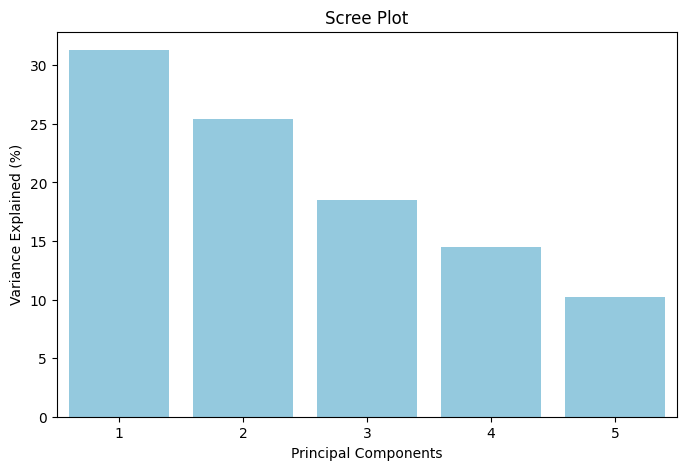

In [ ]:
#Explained Variance Ratio (scree plot)
pca_full = PCA()
pca_full.fit(X_scaled)
explained_var = pca_full.explained_variance_ratio_

plt.figure(figsize=(8,5))
sns.barplot(x=list(range(1,len(explained_var)+1)), y=explained_var*100, color="skyblue")
plt.ylabel('Variance Explained (%)')
plt.xlabel('Principal Components')
plt.title('Scree Plot')
plt.show()

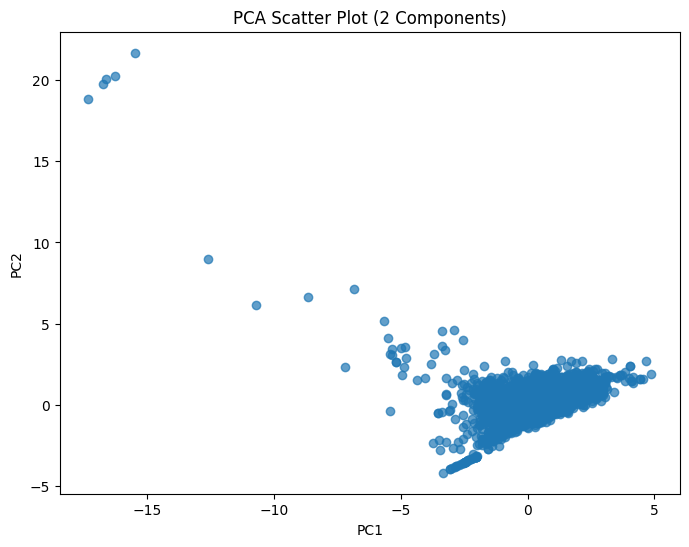

In [ ]:
#PCA with 2 components (for visualization)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Scatter Plot (2 Components)')
plt.show()

In [ ]:
# Interpretation
print("Explained variance by 2 PCs:", pca.explained_variance_ratio_)
print("Total variance explained by 2 PCs:", sum(pca.explained_variance_ratio_))

Explained variance by 2 PCs: [0.31298303 0.25399016]
Total variance explained by 2 PCs: 0.5669731946369541


In [ ]:
# Loadings (Feature contribution to components)
loadings = pd.DataFrame(
    pca.components_,
    columns=final_features,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print("\nPCA Loadings Matrix:")
print(loadings)



PCA Loadings Matrix:
     budget_log    profit       ROI  vote_average   runtime
PC1    0.544030  0.385842 -0.399171      0.377084  0.503615
PC2   -0.449449  0.176332  0.561096      0.554923  0.379651


#**PCA successfully reduced dimensionality while retaining the main variance in the data.:**



PC1 captures overall movie commercial performance, strongly influenced by vote count, vote average, popularity, and runtime, reflecting the general appeal and audience engagement of the film.

PC2 represents contrasts in audience engagement versus runtime, showing that movies with higher popularity or votes do not always have longer runtime, highlighting a trade-off between audience attention and film length.

